# Import the Dependencies

In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Initialize dataframe

In [ ]:
df = pd.read_csv('/content/Covid Data.csv')
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


# Read Dataset

In [ ]:
print('Data Shape: ',df.shape)


Data Shape:  (1048575, 21)


In [ ]:
df.columns


Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED',
       'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
       'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU'],
      dtype='object')

### **Column Definitions¶**


*   USMER : This indicates whether the patient treated medical units of the first, second or third level


*   MEDICAL_UNIT : The type of institution of the Natinal Health System that provided the care.
*   SEX : 1-"Female", 2-"male".


*    PATIENT_TYPE : The type of care the patient received in the unit. 1-"returned home", 2-"hospitalization". 97 and 99 are missing data.
*   DATE_DIED : Indicated date of death means that the patient died, except for 9999-99-99 which means that the patient survived..

*   INTUBED : Wether the patient was connected to a ventilator. 1-"yes", 2-"no"
*    PNEUMONIA : Whether the patient already have air sacs inflamation or not.1-"yes", 2-"no", while 97 and 99 are missing data.

*   AGE: The patient's age.
*   PREGNANT: Whether the patient is pregnant or not.1-"yes", 2-"no", while 97 and 99 are missing data.

*   DIABETES : Whether the patient has diabetes or not.

*   COPD : Whether the patient has chronic obstructive pulmonary disease or not.

*   ASTHMA : Whether the patient has asthma or not.
*   INMSUPR : Whether the patient is immunosuppressed or not.


*   HYPERTENSION : Whether the patient has hypertension or not.
  

*   OTHER DISEASE : Whether the patient has other disease or not.

*   CARDIOVASCULAR : Whether the patient has patient has heart or blood vessels related diseases.

*   OBESITY : Whether the patient is obessed or not.
*   RENAL CHRONIC : Whether the patient has chronic renal disease or not.


*   TOBACCO : Whether the patient is a tobacco user or not.


*   CLASIFFICATION_FINAL : Covid test findings. Values 1-3 means that the patient was diagnosed with covid in different degrees. 4 or higher means that the patient is not a carrier of covid or that the test is inconclusive.

*   ICU : Whether the patient has been admitted into the intensive care unit.




















In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575 non-null  int64 
 15

In [ ]:
df.describe()


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01


In [ ]:
df.columns = df.columns.str.lower()


In [ ]:
df.head()


,usmer,medical_unit,sex,patient_type,date_died,intubed,pneumonia,age,pregnant,diabetes,...,asthma,inmsupr,hipertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,clasiffication_final,icu
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [ ]:
df.describe()


,usmer,medical_unit,sex,patient_type,intubed,pneumonia,age,pregnant,diabetes,copd,asthma,inmsupr,hipertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,clasiffication_final,icu
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01


# Removing Missing Data/ Cleaning Dataset


**Here we will see the number of unique values ​​by column¶**


In [ ]:
for col in df.columns :
    print('{:<20} => {:>5}'.format(col, len(df[col].unique())))

usmer                =>     2
medical_unit         =>    13
sex                  =>     2
patient_type         =>     2
date_died            =>   401
intubed              =>     4
pneumonia            =>     3
age                  =>   121
pregnant             =>     4
diabetes             =>     3
copd                 =>     3
asthma               =>     3
inmsupr              =>     3
hipertension         =>     3
other_disease        =>     3
cardiovascular       =>     3
obesity              =>     3
renal_chronic        =>     3
tobacco              =>     3
clasiffication_final =>     7
icu                  =>     4


**We can display several columns that have unique data above 2 and less than 4 containing missing values¶**


In [ ]:
missing_value_columns = [col for col in df.columns if len(df[col].unique()) >2 and len(df[col].unique())<=4]
missing_value_columns

['intubed',
 'pneumonia',
 'pregnant',
 'diabetes',
 'copd',
 'asthma',
 'inmsupr',
 'hipertension',
 'other_disease',
 'cardiovascular',
 'obesity',
 'renal_chronic',
 'tobacco',
 'icu']

**The following columns (14 of them) of the data needs to be examined in order to remove missing values from them:**


*   intubed

*   pneumonia

*   pregnant

*   diabetes

*   copd
*   asthma


*   inmsupr


*   hypertension


*   other disease


*   cardivascular

*   obesity

*   renal_chronic
*   tobacco


*   icu




--
Notice that these columns contains more than 2 unique values indicating yes or no.



We can see the percentage of missing values ​​from each column, the missing values ​​in this dataset are represented by data 97, 98,¶


In [ ]:
print('Persentase missing values')
for col in df.columns :
    print('{:<20} => {:>10.2f}%'.format(col, len(df[(df[col]==98) | (df[col]==99) | (df[col]==97)])/len(df)*100))

Persentase missing values
usmer                =>       0.00%
medical_unit         =>       0.00%
sex                  =>       0.00%
patient_type         =>       0.00%
date_died            =>       0.00%
intubed              =>      81.62%
pneumonia            =>       1.53%
age                  =>       0.03%
pregnant             =>      50.28%
diabetes             =>       0.32%
copd                 =>       0.29%
asthma               =>       0.28%
inmsupr              =>       0.32%
hipertension         =>       0.30%
other_disease        =>       0.48%
cardiovascular       =>       0.29%
obesity              =>       0.29%
renal_chronic        =>       0.29%
tobacco              =>       0.31%
clasiffication_final =>       0.00%
icu                  =>      81.64%


**Look at the distribution of existing data in the columns that contain missing values¶**


In [ ]:
for column in missing_value_columns:
  print(f"Column: {column}")
  print(df[column].value_counts(normalize=True).mul(100).round(2).sort_values(ascending=False).apply(lambda x: str(x) + '%'))
  print()

Column: intubed
97    80.92%
2     15.17%
1      3.21%
99      0.7%
Name: intubed, dtype: object

Column: pneumonia
2     85.12%
1     13.36%
99     1.53%
Name: pneumonia, dtype: object

Column: pregnant
97    49.93%
2     48.94%
1      0.78%
98     0.36%
Name: pregnant, dtype: object

Column: diabetes
2     87.76%
1     11.92%
98     0.32%
Name: diabetes, dtype: object

Column: copd
2     98.28%
1      1.44%
98     0.29%
Name: copd, dtype: object

Column: asthma
2     96.7%
1     3.01%
98    0.28%
Name: asthma, dtype: object

Column: inmsupr
2     98.32%
1      1.35%
98     0.32%
Name: inmsupr, dtype: object

Column: hipertension
2     84.18%
1     15.52%
98      0.3%
Name: hipertension, dtype: object

Column: other_disease
2     96.84%
1      2.67%
98     0.48%
Name: other_disease, dtype: object

Column: cardiovascular
2     97.73%
1      1.98%
98     0.29%
Name: cardiovascular, dtype: object

Column: obesity
2     84.47%
1     15.24%
98     0.29%
Name: obesity, dtype: object

Column

**From the results above, we can delete columns that have a missing value > 50%. Why do we immediately do column deletion? Because these columns have more missing values ​​than the data we need for data processing. Better we just delete the column**

# Pre-Processing¶


We will delete the "intubed", "pregnant" and "icu" columns because the data in these columns has a missing value of more than 80%

In [ ]:
data_to_remove = ["intubed", "pregnant","icu"]
df.drop(data_to_remove, axis=1, inplace=True)

for data in data_to_remove:
 if data in missing_value_columns:
    missing_value_columns.remove(data)

We can see in the results of the line of code below, if the "intubed", "pregnant" and "icu" columns are gone¶

In [ ]:
df.columns

Index(['usmer', 'medical_unit', 'sex', 'patient_type', 'date_died',
       'pneumonia', 'age', 'diabetes', 'copd', 'asthma', 'inmsupr',
       'hipertension', 'other_disease', 'cardiovascular', 'obesity',
       'renal_chronic', 'tobacco', 'clasiffication_final'],
      dtype='object')

Delete rows of data that contain the missing values ​​97, 98, 99¶


In [ ]:
for col in missing_value_columns:
    df = df[df[col]<97]

In [ ]:
for col in df.columns :
    print('{:<20} => {:>5}'.format(col, len(df[col].unique())))

usmer                =>     2
medical_unit         =>    13
sex                  =>     2
patient_type         =>     2
date_died            =>   395
pneumonia            =>     2
age                  =>   121
diabetes             =>     2
copd                 =>     2
asthma               =>     2
inmsupr              =>     2
hipertension         =>     2
other_disease        =>     2
cardiovascular       =>     2
obesity              =>     2
renal_chronic        =>     2
tobacco              =>     2
clasiffication_final =>     7


Great, for missing values ​​now it's safe. Next, we will process the data in the date-died column. What you need to know is that the indication of the date of death means the patient died, except for 9999-99-99 which means the patient survived¶

For the treatment we will do to the data in the date-died column, we will replace the data 9999-99-99 to 1 which indicates the patient is safe, while the date of death data will be changed to 0 which indicates the patient died.

In [ ]:
df.date_died.value_counts()


9999-99-99    950438
06/07/2020       984
07/07/2020       981
13/07/2020       969
16/06/2020       965
               ...  
27/02/2021         1
26/02/2021         1
20/02/2021         1
11/02/2021         1
22/04/2021         1
Name: date_died, Length: 395, dtype: int64

In [ ]:
df["death"] = [1 if row=='9999-99-99' else 0 for row in df["date_died"]]


In [ ]:
df["death"].value_counts()


1    950438
0     74714
Name: death, dtype: int64

Deleted the "date-died" column, because we've replaced it with the death column¶


In [ ]:
df.drop("date_died", axis=1, inplace=True)
df.head()

,usmer,medical_unit,sex,patient_type,pneumonia,age,diabetes,copd,asthma,inmsupr,hipertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,clasiffication_final,death
0,2,1,1,1,1,65,2,2,2,2,1,2,2,2,2,2,3,0
1,2,1,2,1,1,72,2,2,2,2,1,2,2,1,1,2,5,0
2,2,1,2,2,2,55,1,2,2,2,2,2,2,2,2,2,3,0
3,2,1,1,1,2,53,2,2,2,2,2,2,2,2,2,2,7,0
4,2,1,2,1,2,68,1,2,2,2,1,2,2,2,2,2,3,0


In [ ]:
print('Data Shape After Handling Missing Value: ',df.shape)


Data Shape After Handling Missing Value:  (1025152, 18)


# Selecting Features and Target from our Dataset

The "death" column will be our target variable since we are to make predictions on it.¶


In [ ]:
X = df.drop("death", axis=1).values
y = df["death"].values


There is an Unbalanced Dataset Problem Use the Undersampling method to balance the dataset

Text(0.5, 1.0, 'Death Distribution')

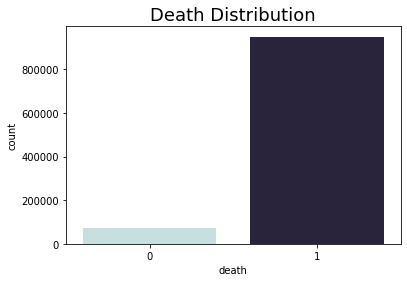

In [ ]:
import seaborn as sns
import  matplotlib.pyplot as plt

ax = sns.countplot(x=df['death'],palette='ch:start=.2,rot=-.3')
plt.title('Death Distribution', fontsize=18)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rand_under = RandomUnderSampler(random_state=0)
X, y = rand_under.fit_resample(X,y)

Text(0.5, 1.0, 'Death Distribution After Resampling')

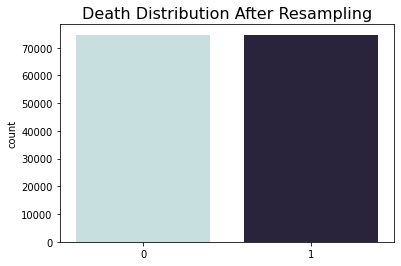

In [ ]:
ax = sns.countplot(x=y,palette='ch:start=.2,rot=-.3')
plt.title("Death Distribution After Resampling", fontsize=16)

# Standardizing the features of our dataset¶

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
print('X : \n',X[:10])
print('\ny : \n',y[:10])

X : 
 [[ 0.90843445 -1.84153899 -1.1392242  -1.04143932 -1.22947388  0.75890983
   0.55531365  0.17983099  0.16042027  0.15171352 -1.60935837  0.20751353
   0.19704582  0.47806442  0.21412759  0.30248323 -0.8763    ]
 [ 0.90843445 -1.84153899  0.87779034 -1.04143932 -1.22947388  1.13237624
   0.55531365  0.17983099  0.16042027  0.15171352 -1.60935837  0.20751353
   0.19704582 -2.0917683  -4.67011271  0.30248323  0.16834177]
 [ 0.90843445 -1.84153899  0.87779034  0.96020957  0.81335604  0.22538641
  -1.80078413  0.17983099  0.16042027  0.15171352  0.62136564  0.20751353
   0.19704582  0.47806442  0.21412759  0.30248323 -0.8763    ]
 [ 0.90843445 -1.84153899 -1.1392242  -1.04143932  0.81335604  0.11868172
   0.55531365  0.17983099  0.16042027  0.15171352  0.62136564  0.20751353
   0.19704582  0.47806442  0.21412759  0.30248323  1.21298353]
 [ 0.90843445 -1.84153899  0.87779034 -1.04143932  0.81335604  0.91896686
  -1.80078413  0.17983099  0.16042027  0.15171352 -1.60935837  0.20751353
  

# Splitting our Dataset

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print('Train X :', X_train.shape)
print('Test X :', X_test.shape)
print('Train Y :', y_train.shape)
print('Test Y :', y_test.shape)

Train X : (119542, 17)
Test X : (29886, 17)
Train Y : (119542,)
Test Y : (29886,)


# Machine Learning (Classification)

We will be making use of the following classification algorithms:


1. Logistic Regression
2. K-Nearest Neighbor



In [ ]:


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from yellowbrick.classifier import ClassificationReport
from sklearn.ensemble import RandomForestClassifier


# **Logistic Regression**


In [ ]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)
prediction_logistic = logistic_model.predict(X_test)
logistic_score = accuracy_score(y_test, prediction_logistic)*100
print(f"The accuracy of the Logistic Regression Model on the validation data is {round(logistic_score, 2)}%")

The accuracy of the Logistic Regression Model on the validation data is 91.08%


The Logistic Regression Classification Report¶


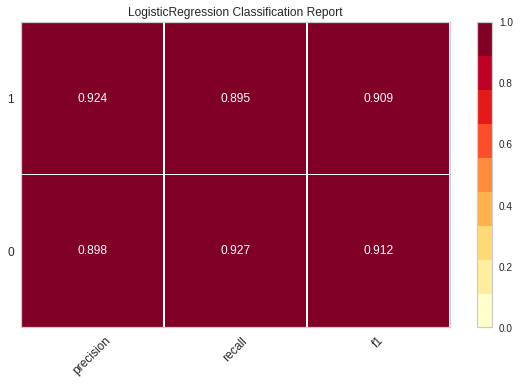

In [ ]:
logistic_model = LogisticRegression()
logistic_model = ClassificationReport(logistic_model, support=False)
logistic_model.fit(X_train, y_train)
logistic_model.score(X_test, y_test)
logistic_model.show()

# **K-Nearest Neighbor**

In [ ]:
KNN_model = KNeighborsClassifier(n_neighbors = 6, metric = 'minkowski', p = 2)
KNN_model.fit(X_train, y_train)
prediction_random = KNN_model.predict(X_test)
KNN_score = accuracy_score(y_test, prediction_random)*100
random_forest_score = accuracy_score(y_test, prediction_random)*100
print(f"The accuracy of the K-Nearest Neighbor Model on the validation data is {round(random_forest_score, 2)}%")

The accuracy of the K-Nearest Neighbor Model on the validation data is 91.24%


The K-NN Classification Report

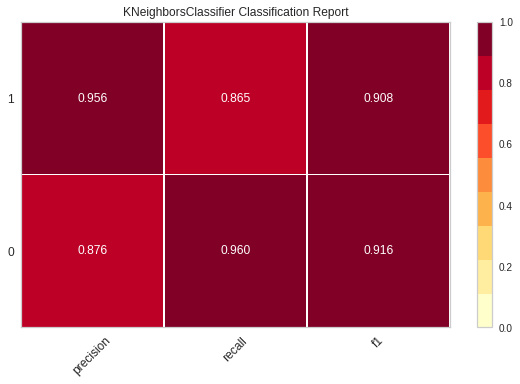

In [ ]:
KNN_model = KNeighborsClassifier(n_neighbors = 6, metric = 'minkowski', p = 2)
KNN_model = ClassificationReport(KNN_model, support=False)
KNN_model.fit(X_train, y_train)
KNN_model.score(X_test, y_test)
KNN_model.show()